# Thermal Design and Performance Analysis of a Shell-and-Tube Heat Exchanger using Python

---

## Objective

This notebook performs the preliminary thermal design of a Shell-and-Tube Heat Exchanger.

The user can

- Select Hot Fluid
- Select Cold Fluid
- Enter Operating Conditions
- Calculate Heat Duty
- Calculate LMTD
- Calculate Reynolds Number
- Calculate Prandtl Number
- Calculate Nusselt Number
- Calculate Heat Transfer Coefficient
- Calculate Overall Heat Transfer Coefficient
- Calculate Heat Transfer Area
- Calculate Tube Count
- Calculate NTU
- Calculate Effectiveness
- Calculate Pressure Drop
- Estimate Cost
- Generate Engineering Graphs

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

In [2]:
# ==================================================
# FLUID PROPERTY DATABASE
# ==================================================

fluids = {

    1:{
        "name":"Water",
        "cp":4180,
        "rho":1000,
        "mu":0.001,
        "k":0.60
    },

    2:{
        "name":"Engine Oil",
        "cp":2100,
        "rho":900,
        "mu":0.25,
        "k":0.145
    },

    3:{
        "name":"Kerosene",
        "cp":2200,
        "rho":820,
        "mu":0.0018,
        "k":0.145
    },

    4:{
        "name":"Benzene",
        "cp":1740,
        "rho":876,
        "mu":0.00065,
        "k":0.167
    },

    5:{
        "name":"Ethylene Glycol",
        "cp":2410,
        "rho":1110,
        "mu":0.016,
        "k":0.252
    },

    6:{
        "name":"Crude Oil",
        "cp":2000,
        "rho":870,
        "mu":0.05,
        "k":0.13
    }

}

In [3]:
print("="*60)
print("AVAILABLE FLUIDS")
print("="*60)

for key,value in fluids.items():
    print(f"{key}. {value['name']}")

while True:

    hot_choice = int(input("\nSelect Hot Fluid (1-6): "))

    if hot_choice in fluids:
        break

    print("Invalid Choice")

while True:

    cold_choice = int(input("\nSelect Cold Fluid (1-6): "))

    if cold_choice in fluids:
        break

    print("Invalid Choice")

hot = fluids[hot_choice]
cold = fluids[cold_choice]

print("\nSelected Fluids")

print("Hot Fluid :",hot["name"])

print("Cold Fluid :",cold["name"])

AVAILABLE FLUIDS
1. Water
2. Engine Oil
3. Kerosene
4. Benzene
5. Ethylene Glycol
6. Crude Oil



Select Hot Fluid (1-6):  2

Select Cold Fluid (1-6):  1



Selected Fluids
Hot Fluid : Engine Oil
Cold Fluid : Water


In [4]:
print("="*60)
print("ENTER OPERATING CONDITIONS")
print("="*60)

m_hot=float(input("Hot Fluid Flow Rate (kg/s): "))

Th_in=float(input("Hot Fluid Inlet Temperature (°C): "))

Th_out=float(input("Hot Fluid Outlet Temperature (°C): "))

Tc_in=float(input("Cold Fluid Inlet Temperature (°C): "))

Tc_out=float(input("Cold Fluid Outlet Temperature (°C): "))

tube_diameter=float(input("Tube Diameter (m): "))

tube_length=float(input("Tube Length (m): "))

ENTER OPERATING CONDITIONS


Hot Fluid Flow Rate (kg/s):  1
Hot Fluid Inlet Temperature (°C):  150
Hot Fluid Outlet Temperature (°C):  70
Cold Fluid Inlet Temperature (°C):  30
Cold Fluid Outlet Temperature (°C):  60
Tube Diameter (m):  0.019
Tube Length (m):  6


In [5]:
cp_hot = hot["cp"]
cp_cold = cold["cp"]

rho_hot = hot["rho"]
rho_cold = cold["rho"]

mu_hot = hot["mu"]
mu_cold = cold["mu"]

k_hot = hot["k"]
k_cold = cold["k"]

print("="*60)
print("FLUID PROPERTIES LOADED")
print("="*60)

print(f"Hot Fluid : {hot['name']}")
print(f"Cp = {cp_hot}")
print(f"Density = {rho_hot}")
print(f"Viscosity = {mu_hot}")
print(f"K = {k_hot}")

print()

print(f"Cold Fluid : {cold['name']}")
print(f"Cp = {cp_cold}")
print(f"Density = {rho_cold}")
print(f"Viscosity = {mu_cold}")
print(f"K = {k_cold}")

FLUID PROPERTIES LOADED
Hot Fluid : Engine Oil
Cp = 2100
Density = 900
Viscosity = 0.25
K = 0.145

Cold Fluid : Water
Cp = 4180
Density = 1000
Viscosity = 0.001
K = 0.6


In [6]:
# ==================================================
# FUNCTIONS
# ==================================================

def heat_duty(m_dot, cp, Tin, Tout):
    """
    Heat Duty
    Q = m × Cp × ΔT
    Returns Heat Duty in Watts
    """
    return m_dot * cp * (Tin - Tout)

def cooling_fluid_flow(Q, cp, Tin, Tout):
    """
    Calculates required cooling fluid mass flow rate
    """
    return Q / (cp * (Tout - Tin))

def lmtd(Th_in, Th_out, Tc_in, Tc_out):
    """
    Log Mean Temperature Difference
    Counter-current heat exchanger
    """
    deltaT1 = Th_in - Tc_out
    deltaT2 = Th_out - Tc_in

    if deltaT1 <= 0 or deltaT2 <= 0:
        raise ValueError("Invalid temperatures. LMTD cannot be calculated.")

    return (deltaT1 - deltaT2) / math.log(deltaT1 / deltaT2)

def heat_transfer_area(Q, U, LMTD):
    """
    Required Heat Transfer Area
    """
    return Q / (U * LMTD)

def tube_area(diameter, length):
    """
    Area of one tube
    """
    return math.pi * diameter * length

def tube_count(total_area, single_tube_area):
    """
    Number of tubes required
    """
    return math.ceil(total_area / single_tube_area)

In [7]:
# ==================================================
# HEAT DUTY
# ==================================================

Q = heat_duty(
    m_hot,
    cp_hot,
    Th_in,
    Th_out
)

print("="*60)
print("THERMAL DESIGN")
print("="*60)

print(f"Heat Duty = {Q/1000:.2f} kW")

# ==================================================
# COOLING FLUID FLOW RATE
# ==================================================

m_cold = cooling_fluid_flow(
    Q,
    cp_cold,
    Tc_in,
    Tc_out
)

print(f"Required {cold['name']} Flow Rate = {m_cold:.3f} kg/s")

THERMAL DESIGN
Heat Duty = 168.00 kW
Required Water Flow Rate = 1.340 kg/s


In [8]:
# ==================================================
# LMTD
# ==================================================

LMTD = lmtd(
    Th_in,
    Th_out,
    Tc_in,
    Tc_out
)

print("="*60)
print(f"LMTD = {LMTD:.2f} °C")

LMTD = 61.66 °C


In [9]:
# ==================================================
# REYNOLDS NUMBER
# ==================================================

def reynolds_number(m_dot, diameter, viscosity):
    return (4 * m_dot) / (math.pi * diameter * viscosity)


Re = reynolds_number(
    m_hot,
    tube_diameter,
    mu_hot
)

print("="*60)
print(f"Reynolds Number = {Re:.2f}")

if Re < 2300:
    print("Flow Regime : Laminar")
elif Re < 4000:
    print("Flow Regime : Transitional")
else:
    print("Flow Regime : Turbulent")

Reynolds Number = 268.05
Flow Regime : Laminar


In [10]:
# ==================================================
# PRANDTL NUMBER
# ==================================================

def prandtl_number(cp, viscosity, conductivity):

    return (cp * viscosity) / conductivity


Pr = prandtl_number(
    cp_hot,
    mu_hot,
    k_hot
)

print("="*60)
print(f"Prandtl Number = {Pr:.2f}")

Prandtl Number = 3620.69


In [11]:
# ==================================================
# NUSSELT NUMBER
# ==================================================

def nusselt_number(Re, Pr, D, L):
    """
    Automatically selects the appropriate Nusselt correlation.

    Laminar Flow      : Sieder-Tate
    Transitional Flow : Dittus-Boelter (Approximation)
    Turbulent Flow    : Dittus-Boelter
    """

    # Laminar Flow
    if Re < 2300:
        mu_ratio = 1.0      # Assume μ/μw = 1
        Nu = 1.86 * ((Re * Pr * D / L) ** (1/3)) * (mu_ratio ** 0.14)
        correlation = "Sieder-Tate"

    # Transitional Flow
    elif Re < 10000:
        Nu = 0.023 * (Re ** 0.8) * (Pr ** 0.4)
        correlation = "Dittus-Boelter (Preliminary Design Approximation)"

    # Turbulent Flow
    else:
        Nu = 0.023 * (Re ** 0.8) * (Pr ** 0.4)
        correlation = "Dittus-Boelter"

    return Nu, correlation


Nu, correlation = nusselt_number(
    Re,
    Pr,
    tube_diameter,
    tube_length
)

print("="*60)
print("CONVECTIVE HEAT TRANSFER ANALYSIS")
print("="*60)

print(f"Reynolds Number      : {Re:.2f}")
print(f"Prandtl Number       : {Pr:.2f}")
print(f"Nusselt Number       : {Nu:.2f}")
print(f"Correlation Used     : {correlation}")

if 2300 <= Re < 10000:

    print("\nNote:")
    print("Flow lies in the transitional regime.")
    print("Dittus-Boelter correlation is used as a preliminary design approximation.")

CONVECTIVE HEAT TRANSFER ANALYSIS
Reynolds Number      : 268.05
Prandtl Number       : 3620.69
Nusselt Number       : 27.04
Correlation Used     : Sieder-Tate


In [12]:
# ==================================================
# TUBE-SIDE HEAT TRANSFER COEFFICIENT
# ==================================================

def tube_side_h(Nu, k, D):
    """
    Calculate tube-side heat transfer coefficient.

    h = Nu*k/D
    """
    return Nu * k / D

hi = tube_side_h(
    Nu,
    k_hot,
    tube_diameter
)

print("="*60)
print("TUBE-SIDE HEAT TRANSFER")
print("="*60)

print(f"Tube-side Heat Transfer Coefficient = {hi:.2f} W/m².K")

TUBE-SIDE HEAT TRANSFER
Tube-side Heat Transfer Coefficient = 206.38 W/m².K


In [13]:
# ==================================================
# SHELL-SIDE HEAT TRANSFER COEFFICIENT
# ==================================================

shell_side_h = {
    "Water":2500,
    "Engine Oil":250,
    "Kerosene":450,
    "Benzene":700,
    "Ethylene Glycol":800,
    "Crude Oil":180
}

ho = shell_side_h[cold["name"]]

print("="*60)
print("SHELL SIDE HEAT TRANSFER")
print("="*60)

print(f"Shell-side Heat Transfer Coefficient = {ho:.2f} W/m².K")

print("\nAssumption:")
print("Typical shell-side heat transfer coefficient is used.")

SHELL SIDE HEAT TRANSFER
Shell-side Heat Transfer Coefficient = 2500.00 W/m².K

Assumption:
Typical shell-side heat transfer coefficient is used.


In [14]:
# ==================================================
# OVERALL HEAT TRANSFER COEFFICIENT
# ==================================================

tube_thickness = 0.002      # m

tube_conductivity = 16       # Stainless Steel W/m.K

Rw = tube_thickness / tube_conductivity

U = 1 / ((1/hi) + Rw + (1/ho))

print("="*60)
print("OVERALL HEAT TRANSFER COEFFICIENT")
print("="*60)

print(f"Tube Wall Resistance = {Rw:.6f}")
print(f"Overall Heat Transfer Coefficient = {U:.2f} W/m².K")

OVERALL HEAT TRANSFER COEFFICIENT
Tube Wall Resistance = 0.000125
Overall Heat Transfer Coefficient = 186.20 W/m².K


In [15]:
# ==================================================
# HEAT TRANSFER AREA
# ==================================================

Area = heat_transfer_area(
    Q,
    U,
    LMTD
)

Atube = tube_area(
    tube_diameter,
    tube_length
)

Ntubes = tube_count(
    Area,
    Atube
)

print("="*60)
print("HEAT EXCHANGER SIZING")
print("="*60)

print(f"Required Heat Transfer Area = {Area:.2f} m²")
print(f"Area of One Tube = {Atube:.3f} m²")
print(f"Required Number of Tubes = {Ntubes}")

HEAT EXCHANGER SIZING
Required Heat Transfer Area = 14.63 m²
Area of One Tube = 0.358 m²
Required Number of Tubes = 41


In [16]:
# ==================================================
# NTU
# ==================================================

C_hot = m_hot * cp_hot
C_cold = m_cold * cp_cold
C_min = min(C_hot, C_cold)
C_max = max(C_hot, C_cold)
Cr = C_min / C_max
NTU = (U * Area) / C_min

print("="*60)
print("NTU ANALYSIS")
print("="*60)

print(f"C_hot = {C_hot:.2f} W/K")
print(f"C_cold = {C_cold:.2f} W/K")
print(f"Capacity Ratio = {Cr:.3f}")
print(f"NTU = {NTU:.3f}")

NTU ANALYSIS
C_hot = 2100.00 W/K
C_cold = 5600.00 W/K
Capacity Ratio = 0.375
NTU = 1.297


In [17]:
# ==================================================
# EFFECTIVENESS
# ==================================================

if abs(Cr - 1) < 1e-6:
    epsilon = NTU / (1 + NTU)
else:
    epsilon = (1 - math.exp(-NTU * (1 - Cr))) / (1 - Cr * math.exp(-NTU * (1 - Cr)))

print("="*60)
print("PERFORMANCE")
print("="*60)

print(f"Heat Exchanger Effectiveness = {epsilon:.3f}")

PERFORMANCE
Heat Exchanger Effectiveness = 0.667


In [18]:
# ==================================================
# PRESSURE DROP ANALYSIS
# ==================================================

# Darcy friction factor
f = 0.02

# Flow area of ONE tube
flow_area = math.pi * tube_diameter**2 / 4

# Assume all tubes are active
m_per_tube = m_hot / Ntubes

# Velocity inside one tube
velocity = m_per_tube / (rho_hot * flow_area)

# Darcy-Weisbach Pressure Drop
deltaP = (
    f
    * (tube_length / tube_diameter)
    * (rho_hot * velocity**2 / 2)
)

print("="*60)
print("PRESSURE DROP ANALYSIS")
print("="*60)

print(f"Number of Tubes           : {Ntubes}")
print(f"Mass Flow per Tube        : {m_per_tube:.4f} kg/s")
print(f"Velocity in Each Tube     : {velocity:.3f} m/s")
print(f"Pressure Drop             : {deltaP:.2f} Pa")

PRESSURE DROP ANALYSIS
Number of Tubes           : 41
Mass Flow per Tube        : 0.0244 kg/s
Velocity in Each Tube     : 0.096 m/s
Pressure Drop             : 25.97 Pa


In [19]:
# ==================================================
# COST ESTIMATION
# ==================================================

cost_per_m2 = 1200     # USD/m² (Assumed)
estimated_cost = Area * cost_per_m2

print("="*60)
print("COST ESTIMATION")
print("="*60)

print(f"Heat Transfer Area : {Area:.2f} m²")
print(f"Estimated Cost     : ${estimated_cost:,.2f}")

COST ESTIMATION
Heat Transfer Area : 14.63 m²
Estimated Cost     : $17,559.67


In [20]:
# ==================================================
# DESIGN SUMMARY
# ==================================================

summary = pd.DataFrame({

    "Parameter":[
        "Hot Fluid",
        "Cold Fluid",
        "Heat Duty (kW)",
        "Cooling Fluid Flow (kg/s)",
        "LMTD (°C)",
        "Reynolds Number",
        "Prandtl Number",
        "Nusselt Number",
        "Tube-side h (W/m².K)",
        "Shell-side h (W/m².K)",
        "Overall U (W/m².K)",
        "Heat Transfer Area (m²)",
        "Number of Tubes",
        "NTU",
        "Effectiveness",
        "Pressure Drop (Pa)",
        "Estimated Cost (USD)"
    ],

    "Value":[
        hot["name"],
        cold["name"],
        round(Q/1000,2),
        round(m_cold,2),
        round(LMTD,2),
        round(Re,2),
        round(Pr,2),
        round(Nu,2),
        round(hi,2),
        round(ho,2),
        round(U,2),
        round(Area,2),
        Ntubes,
        round(NTU,3),
        round(epsilon,3),
        round(deltaP,2),
        round(estimated_cost,2)
    ]

})

summary

,Parameter,Value
0,Hot Fluid,Engine Oil
1,Cold Fluid,Water
2,Heat Duty (kW),168.0
3,Cooling Fluid Flow (kg/s),1.34
4,LMTD (°C),61.66
5,Reynolds Number,268.05
6,Prandtl Number,3620.69
7,Nusselt Number,27.04
8,Tube-side h (W/m².K),206.38
9,Shell-side h (W/m².K),2500


In [21]:
import os

os.makedirs("images", exist_ok=True)

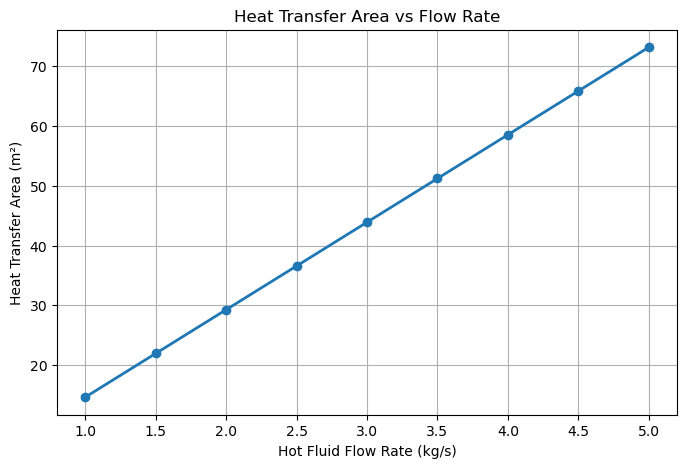

In [22]:
flow_rates = np.arange(1,5.5,0.5)

areas=[]

for flow in flow_rates:

    q=heat_duty(
        flow,
        cp_hot,
        Th_in,
        Th_out
    )

    area=heat_transfer_area(
        q,
        U,
        LMTD
    )

    areas.append(area)

plt.figure(figsize=(8,5))

plt.plot(flow_rates,
         areas,
         marker="o",
         linewidth=2)

plt.grid()
plt.xlabel("Hot Fluid Flow Rate (kg/s)")
plt.ylabel("Heat Transfer Area (m²)")
plt.title("Heat Transfer Area vs Flow Rate")
plt.savefig("area_vs_flow.png",dpi=150, bbox_inches="tight")
plt.show()

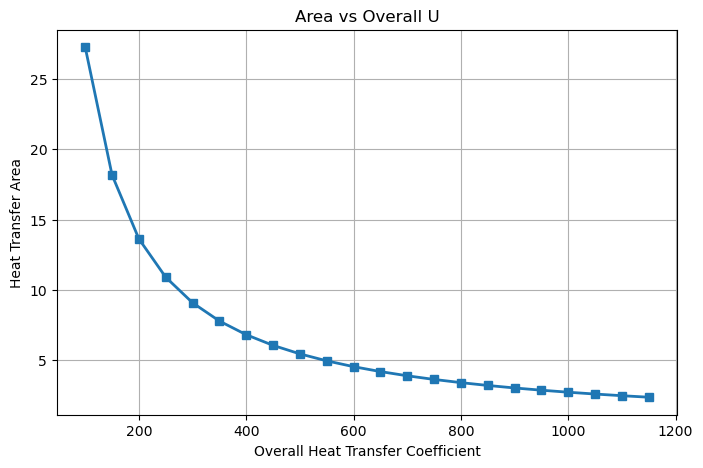

In [23]:
U_values=np.arange(100,1200,50)

areas=[]

for u in U_values:

    area=heat_transfer_area(
        Q,
        u,
        LMTD
    )

    areas.append(area)

plt.figure(figsize=(8,5))

plt.plot(U_values,
         areas,
         marker="s",
         linewidth=2)

plt.grid()
plt.xlabel("Overall Heat Transfer Coefficient")
plt.ylabel("Heat Transfer Area")
plt.title("Area vs Overall U")
plt.savefig("area_vs_U.png", dpi=150, bbox_inches="tight")
plt.show()

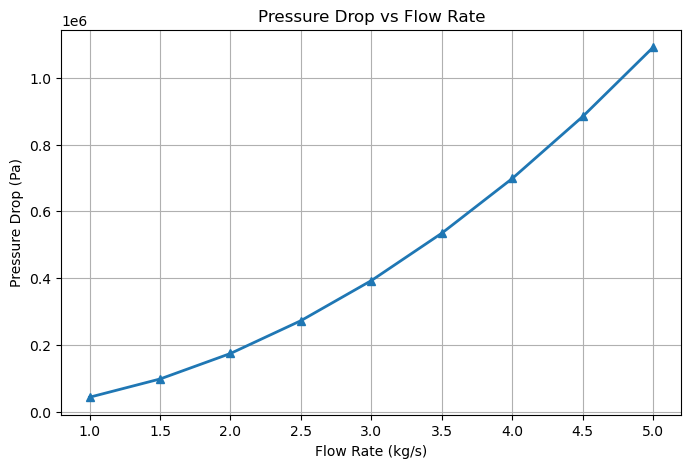

In [24]:
pressure=[]

for flow in flow_rates:
    velocity=flow/(rho_hot*flow_area)
    dp=f*(tube_length/tube_diameter)*(rho_hot*velocity**2/2)
    pressure.append(dp)

plt.figure(figsize=(8,5))
plt.plot(flow_rates,
         pressure,
         marker="^",
         linewidth=2)

plt.grid()
plt.xlabel("Flow Rate (kg/s)")
plt.ylabel("Pressure Drop (Pa)")
plt.title("Pressure Drop vs Flow Rate")
plt.savefig("pressure_drop.png",dpi=150, bbox_inches="tight")
plt.show()

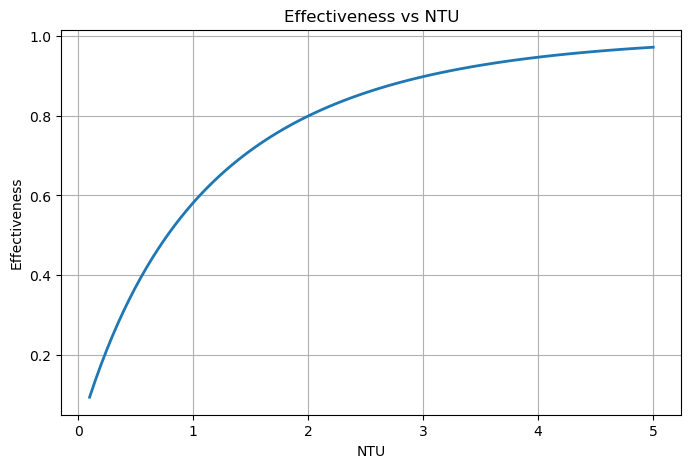

In [25]:
ntu=np.linspace(0.1,5,100)

eps=[]

for n in ntu:

    if abs(Cr-1)<1e-6:
        e=n/(1+n)

    else:
        e=(1-math.exp(-n*(1-Cr))) / (1-Cr*math.exp(-n*(1-Cr)))

    eps.append(e)

plt.figure(figsize=(8,5))
plt.plot(
    ntu,
    eps,
    linewidth=2
)

plt.grid()
plt.xlabel("NTU")
plt.ylabel("Effectiveness")
plt.title("Effectiveness vs NTU")
plt.savefig("effectiveness_vs_ntu.png",dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# Export CSV

summary.to_csv(
    "Heat_Exchanger_Report.csv",
    index=False
)

In [27]:
print("="*70)
print(" SHELL & TUBE HEAT EXCHANGER DESIGN REPORT ")
print("="*70)

print(f"Hot Fluid                 : {hot['name']}")
print(f"Cold Fluid                : {cold['name']}")

print()

print(f"Heat Duty                 : {Q/1000:.2f} kW")
print(f"Cooling Fluid Flow        : {m_cold:.2f} kg/s")
print(f"LMTD                      : {LMTD:.2f} °C")
print(f"Reynolds Number           : {Re:.2f}")
print(f"Prandtl Number            : {Pr:.2f}")
print(f"Nusselt Number            : {Nu:.2f}")
print(f"Tube-side h               : {hi:.2f} W/m².K")
print(f"Shell-side h              : {ho:.2f} W/m².K")
print(f"Overall U                 : {U:.2f} W/m².K")
print(f"Heat Transfer Area        : {Area:.2f} m²")
print(f"Number of Tubes           : {Ntubes}")
print(f"NTU                       : {NTU:.3f}")
print(f"Effectiveness             : {epsilon:.3f}")
print(f"Pressure Drop             : {deltaP:.2f} Pa")
print(f"Estimated Cost            : ${estimated_cost:,.2f}")

print("="*70)

 SHELL & TUBE HEAT EXCHANGER DESIGN REPORT 
Hot Fluid                 : Engine Oil
Cold Fluid                : Water

Heat Duty                 : 168.00 kW
Cooling Fluid Flow        : 1.34 kg/s
LMTD                      : 61.66 °C
Reynolds Number           : 268.05
Prandtl Number            : 3620.69
Nusselt Number            : 27.04
Tube-side h               : 206.38 W/m².K
Shell-side h              : 2500.00 W/m².K
Overall U                 : 186.20 W/m².K
Heat Transfer Area        : 14.63 m²
Number of Tubes           : 41
NTU                       : 1.297
Effectiveness             : 0.667
Pressure Drop             : 25.97 Pa
Estimated Cost            : $17,559.67


In [28]:
import os

print(os.getcwd())

G:\Projects\shell-and-tube-heat-exchanger
